# 📘 Machine Learning Practical Handbook in Python

> **A complete, beginner-to-intermediate ML course with theory, code, and visualizations.**

---
**Libraries used:** `pandas` · `numpy` · `matplotlib` · `seaborn` · `scikit-learn`

**Sections:**
1. Introduction to Machine Learning
2. Data Loading and Exploration
3. Data Preprocessing
4. Supervised Learning – Classification
5. Supervised Learning – Regression
6. Model Evaluation
7. Feature Engineering
8. Unsupervised Learning
9. Hyperparameter Tuning
10. Machine Learning Pipeline
11. Mini Project


## 🔧 Global Imports & Settings

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110




---
# 🧠 Section 1 / Introduction to Machine Learning


## 1.1 What is Machine Learning?

**Machine Learning (ML)** is a sub-field of Artificial Intelligence that gives computers the ability
to *learn from data* and improve their performance on tasks without being explicitly programmed.

**Classic definition (Tom Mitchell, 1997):**
> *"A computer program is said to learn from experience E with respect to some task T and some
> performance measure P, if its performance at T, as measured by P, improves with experience E."*

**Key idea:** Instead of writing rules by hand, we feed examples to an algorithm and let it *discover* the rules.


## 1.2 Types of Machine Learning

| Type | Description | Examples |
|------|-------------|----------|
| **Supervised Learning** | Learn from labeled data (input → output pairs) | Classification, Regression |
| **Unsupervised Learning** | Find hidden patterns in unlabeled data | Clustering, Dimensionality Reduction |
| **Semi-supervised Learning** | Mix of labeled and unlabeled data | Self-training models |
| **Reinforcement Learning** | Agent learns via reward/penalty signals | Game AI, Robotics |

### The ML Workflow
```
Raw Data → Preprocessing → Feature Engineering → Model Training → Evaluation → Deployment
```


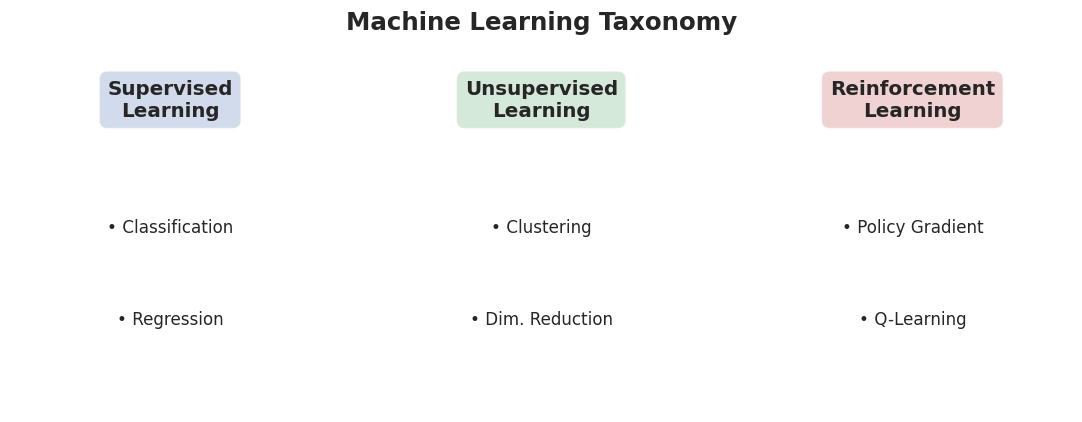

In [2]:
# Visualise the ML taxonomy
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
categories = {
    'Supervised\nLearning':    ['Classification', 'Regression'],
    'Unsupervised\nLearning':  ['Clustering', 'Dim. Reduction'],
    'Reinforcement\nLearning': ['Policy Gradient', 'Q-Learning'],
}
colors = ['#4C72B0', '#55A868', '#C44E52']
x_positions = [0.15, 0.5, 0.85]
for (title, items), x, c in zip(categories.items(), x_positions, colors):
    ax.text(x, 0.85, title, ha='center', va='center', fontsize=13, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=c, alpha=0.25))
    for i, item in enumerate(items):
        ax.text(x, 0.5 - i*0.25, f'• {item}', ha='center', va='center', fontsize=11)
ax.set_title('Machine Learning Taxonomy', fontsize=16, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()


---
# 📊 Section 2 / Data Loading and Exploration

We will use the classic **Iris** dataset for classification tasks and the **California Housing** dataset
for regression tasks — both ship with `scikit-learn`.


In [3]:
from sklearn.datasets import load_iris, load_breast_cancer, fetch_california_housing

#  load iris
iris = load_iris(as_frame=True)
df_iris = iris.frame                        
df_iris['target_name'] = df_iris['target'].map(dict(enumerate(iris.target_names)))

print('Iris dataset shape:', df_iris.shape)
df_iris.head()


Iris dataset shape: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [4]:
df_iris.describe().round(2)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20,1.00
std,0.83,0.44,1.77,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.35,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


In [5]:
print('Class distribution:')
print(df_iris['target_name'].value_counts())


Class distribution:
target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


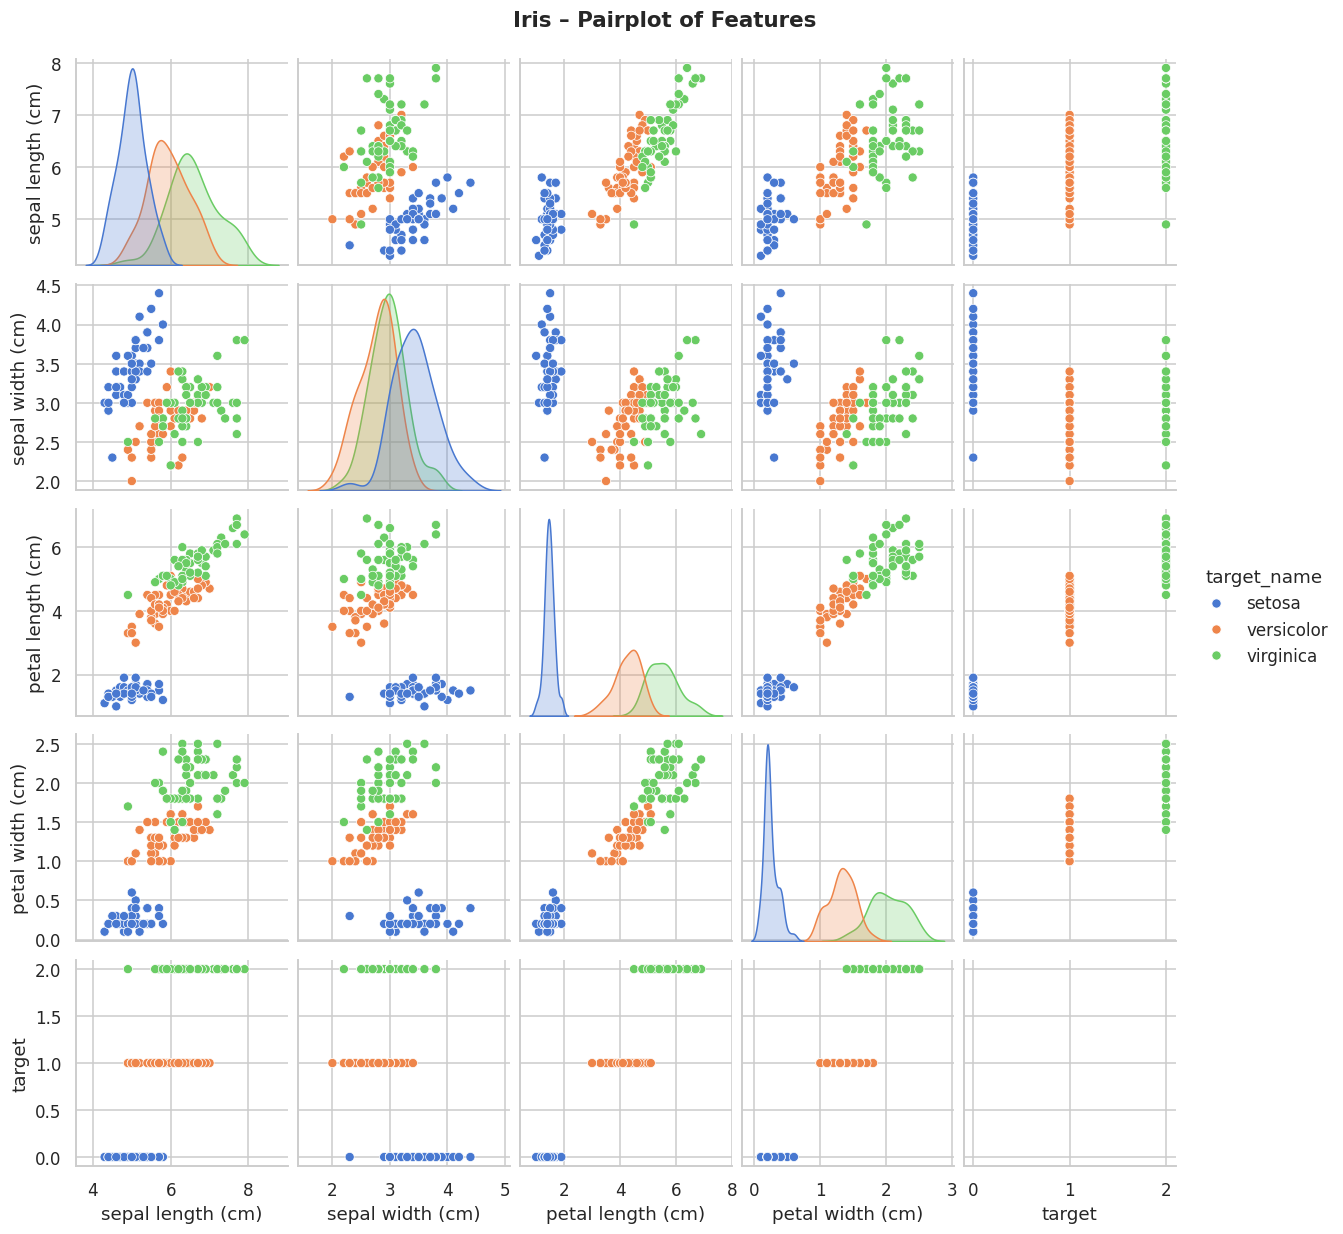

In [6]:
# Pairplot :relationships between all features
sns.pairplot(df_iris, hue='target_name', diag_kind='kde', height=2.2)
plt.suptitle('Iris – Pairplot of Features', y=1.02, fontsize=14, fontweight='bold')
plt.show()


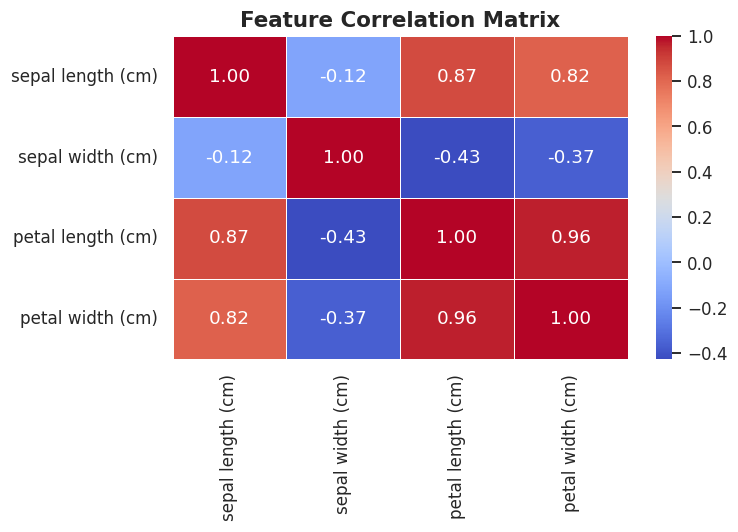

In [7]:
# Correlation heatmap 
fig, ax = plt.subplots(figsize=(7, 5))
corr = df_iris.drop(columns=['target', 'target_name']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


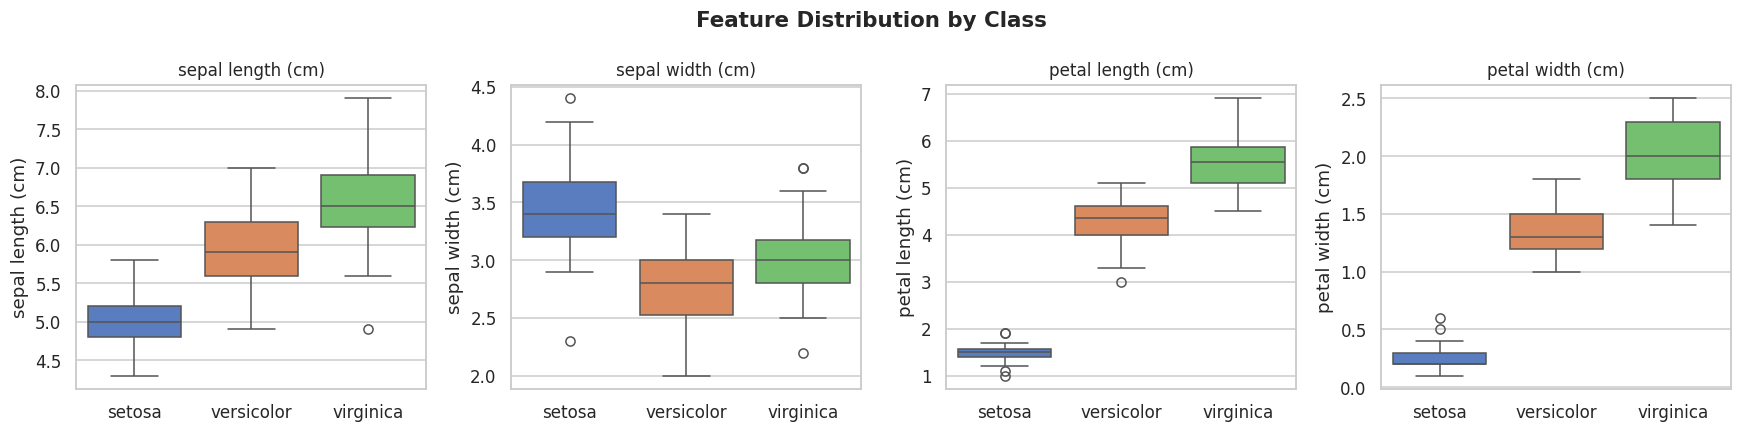

In [8]:
# ── Box plots per feature by class ──────────────────────────────────────────
features = iris.feature_names
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feat in zip(axes, features):
    sns.boxplot(data=df_iris, x='target_name', y=feat, ax=ax, palette='muted')
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel('')
plt.suptitle('Feature Distribution by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
# 🛠️ Section 3 / Data Preprocessing

Real-world data is messy. Preprocessing converts raw data into a clean, model-ready form.


## 3.1 Handling Missing Values

In [9]:
# Create a synthetic dirty version of Iris to demonstrate missing-value handling
np.random.seed(42)
df_dirty = df_iris.copy()
mask = np.random.rand(*df_dirty.shape) < 0.08   # 8% of cells become NaN
df_dirty = df_dirty.where(~mask)

print('Missing values per column:')
print(df_dirty.isnull().sum())


Missing values per column:
sepal length (cm)    12
sepal width (cm)      4
petal length (cm)    17
petal width (cm)      5
target               20
target_name          16
dtype: int64


In [10]:
from sklearn.impute import SimpleImputer

numeric_cols = df_dirty.select_dtypes(include='number').columns.tolist()
numeric_cols.remove('target')   # keep target untouched

# Mean imputation for numeric features
imputer = SimpleImputer(strategy='mean')
df_dirty[numeric_cols] = imputer.fit_transform(df_dirty[numeric_cols])

# Restore categorical target
df_dirty['target'] = df_iris['target']
df_dirty['target_name'] = df_iris['target_name']

print('Missing values after imputation:')
print(df_dirty.isnull().sum())


Missing values after imputation:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
target_name          0
dtype: int64


## 3.2 Label Encoding

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
encoded = le.fit_transform(df_iris['target_name'])
print('Original labels:', df_iris['target_name'].unique())
print('Encoded labels :', le.classes_, '->', le.transform(le.classes_))


Original labels: [np.str_('setosa') np.str_('versicolor') np.str_('virginica')]
Encoded labels : [np.str_('setosa') np.str_('versicolor') np.str_('virginica')] -> [0 1 2]


## 3.3 One-Hot Encoding

In [12]:
# One-hot encoding is preferred when there is no ordinal relationship
ohe_df = pd.get_dummies(df_iris['target_name'], prefix='species')
print(ohe_df.head())


   species_setosa  species_versicolor  species_virginica
0            True               False              False
1            True               False              False
2            True               False              False
3            True               False              False
4            True               False              False


## 3.4 Feature Scaling

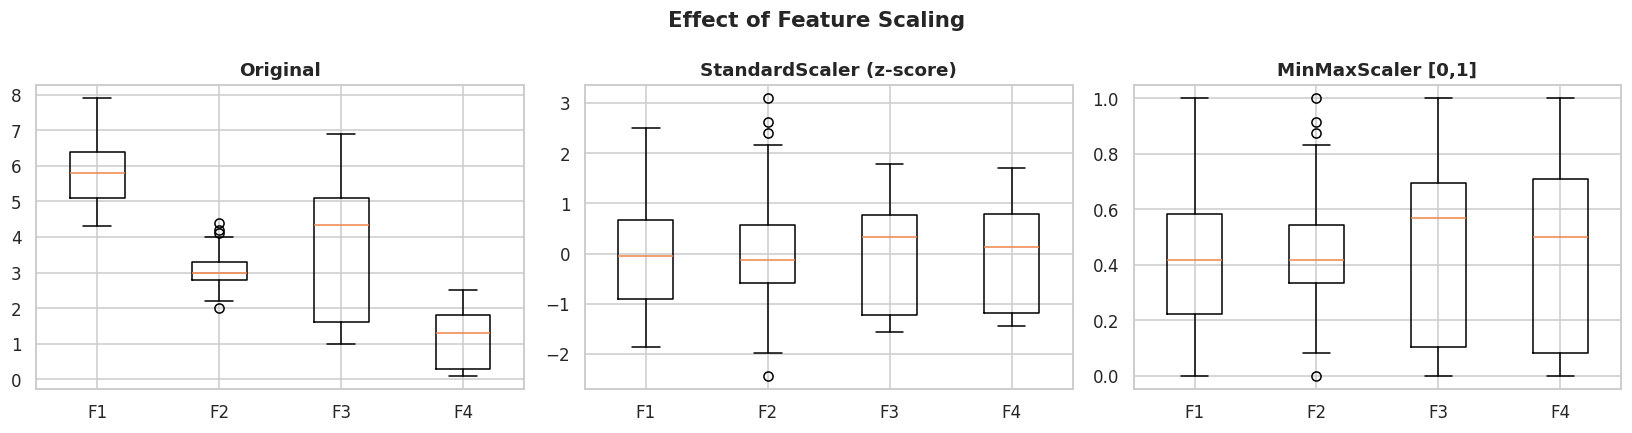

In [13]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

X = df_iris[iris.feature_names].values

std_scaler = StandardScaler()
X_std = std_scaler.fit_transform(X)

mm_scaler = MinMaxScaler()
X_mm = mm_scaler.fit_transform(X)

# Compare distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title in zip(axes,
                             [X, X_std, X_mm],
                             ['Original', 'StandardScaler (z-score)', 'MinMaxScaler [0,1]']):
    ax.boxplot(data, labels=[f'F{i+1}' for i in range(4)])
    ax.set_title(title, fontsize=12, fontweight='bold')
plt.suptitle('Effect of Feature Scaling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 3.5 Train / Test Split

In [14]:
from sklearn.model_selection import train_test_split

X_clf = df_iris[iris.feature_names].values
y_clf = df_iris['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Scale AFTER splitting to prevent data leakage
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit on train only
X_test_s  = scaler.transform(X_test)        # apply same transform to test

print(f'Train size: {X_train.shape[0]} samples')
print(f'Test  size: {X_test.shape[0]} samples')


Train size: 120 samples
Test  size: 30 samples


---
# 🤖 Section 4 / Supervised Learning: Classification

We train seven classifiers on the **Iris** dataset and compare their accuracy.


In [15]:
# Container to collect results for later comparison
clf_results = {}


## 4.x Logistic Regression

A linear model that estimates class probabilities using the **sigmoid / softmax** function.
It minimises log-loss and is fast, interpretable, and a great baseline.


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Instantiate and train
model_LogisticRegression = LogisticRegression(max_iter=200, random_state=42)
model_LogisticRegression.fit(X_train_s, y_train)

# Predict
y_pred_LogisticRegression = model_LogisticRegression.predict(X_test_s)

# Evaluate
acc = accuracy_score(y_test, y_pred_LogisticRegression)
clf_results['Logistic Regression'] = acc
print(f'Logistic Regression — Accuracy: {acc:.4f}')
print(classification_report(y_test, y_pred_LogisticRegression, target_names=iris.target_names))


Logistic Regression — Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## 4.x K-Nearest Neighbors (KNN)

A non-parametric, instance-based learner that classifies a sample by majority vote
among its *k* nearest training neighbours (measured by Euclidean distance by default).


In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# instantiate and train
model_KNeighborsClassifier = KNeighborsClassifier(n_neighbors=5)
model_KNeighborsClassifier.fit(X_train_s, y_train)

# predict
y_pred_KNeighborsClassifier = model_KNeighborsClassifier.predict(X_test_s)

# evaluate
acc = accuracy_score(y_test, y_pred_KNeighborsClassifier)
clf_results['K-Nearest Neighbors (KNN)'] = acc
print(f'K-Nearest Neighbors (KNN) — Accuracy: {acc:.4f}')
print(classification_report(y_test, y_pred_KNeighborsClassifier, target_names=iris.target_names))


K-Nearest Neighbors (KNN) — Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



## 4.x Support Vector Machine (SVM)

SVM finds the **maximum-margin hyperplane** separating classes.
The *kernel trick* (e.g. RBF) maps data to higher dimensions for non-linear boundaries.


In [18]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


model_SVC = SVC(kernel='rbf', C=1.0, random_state=42)
model_SVC.fit(X_train_s, y_train)

y_pred_SVC = model_SVC.predict(X_test_s)

acc = accuracy_score(y_test, y_pred_SVC)
clf_results['Support Vector Machine (SVM)'] = acc
print(f'Support Vector Machine (SVM) — Accuracy: {acc:.4f}')
print(classification_report(y_test, y_pred_SVC, target_names=iris.target_names))


Support Vector Machine (SVM) — Accuracy: 0.9667
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 4.x Decision Tree

Recursively splits the feature space using thresholds chosen to minimise **Gini impurity** or
**entropy**. Easy to interpret but prone to overfitting without depth limits.


In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report


model_DecisionTreeClassifier = DecisionTreeClassifier(max_depth=4, random_state=42)
model_DecisionTreeClassifier.fit(X_train_s, y_train)


y_pred_DecisionTreeClassifier = model_DecisionTreeClassifier.predict(X_test_s)


acc = accuracy_score(y_test, y_pred_DecisionTreeClassifier)
clf_results['Decision Tree'] = acc
print(f'Decision Tree — Accuracy: {acc:.4f}')
print(classification_report(y_test, y_pred_DecisionTreeClassifier, target_names=iris.target_names))


Decision Tree — Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## 4.x Random Forest

An ensemble of decision trees trained on random subsets of data (*bagging*) and features.
Averaging predictions reduces variance and typically outperforms a single tree.


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


model_RandomForestClassifier = RandomForestClassifier(n_estimators=100, random_state=42)
model_RandomForestClassifier.fit(X_train_s, y_train)


y_pred_RandomForestClassifier = model_RandomForestClassifier.predict(X_test_s)


acc = accuracy_score(y_test, y_pred_RandomForestClassifier)
clf_results['Random Forest'] = acc
print(f'Random Forest — Accuracy: {acc:.4f}')
print(classification_report(y_test, y_pred_RandomForestClassifier, target_names=iris.target_names))


Random Forest — Accuracy: 0.9000
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



## 4.x Naive Bayes

Applies **Bayes' theorem** assuming features are conditionally independent given the class
(the 'naive' assumption). Despite this strong assumption it works surprisingly well in practice.


In [21]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report


model_GaussianNB = GaussianNB()
model_GaussianNB.fit(X_train_s, y_train)


y_pred_GaussianNB = model_GaussianNB.predict(X_test_s)


acc = accuracy_score(y_test, y_pred_GaussianNB)
clf_results['Naive Bayes'] = acc
print(f'Naive Bayes — Accuracy: {acc:.4f}')
print(classification_report(y_test, y_pred_GaussianNB, target_names=iris.target_names))


Naive Bayes — Accuracy: 0.9667
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 4.x Gradient Boosting

Builds trees **sequentially**, each correcting residual errors of the previous ensemble.
Often achieves state-of-the-art results on tabular data.


In [22]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report


model_GradientBoostingClassifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
model_GradientBoostingClassifier.fit(X_train_s, y_train)


y_pred_GradientBoostingClassifier = model_GradientBoostingClassifier.predict(X_test_s)


acc = accuracy_score(y_test, y_pred_GradientBoostingClassifier)
clf_results['Gradient Boosting'] = acc
print(f'Gradient Boosting — Accuracy: {acc:.4f}')
print(classification_report(y_test, y_pred_GradientBoostingClassifier, target_names=iris.target_names))


Gradient Boosting — Accuracy: 0.9667
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 4.8 Classifier Comparison

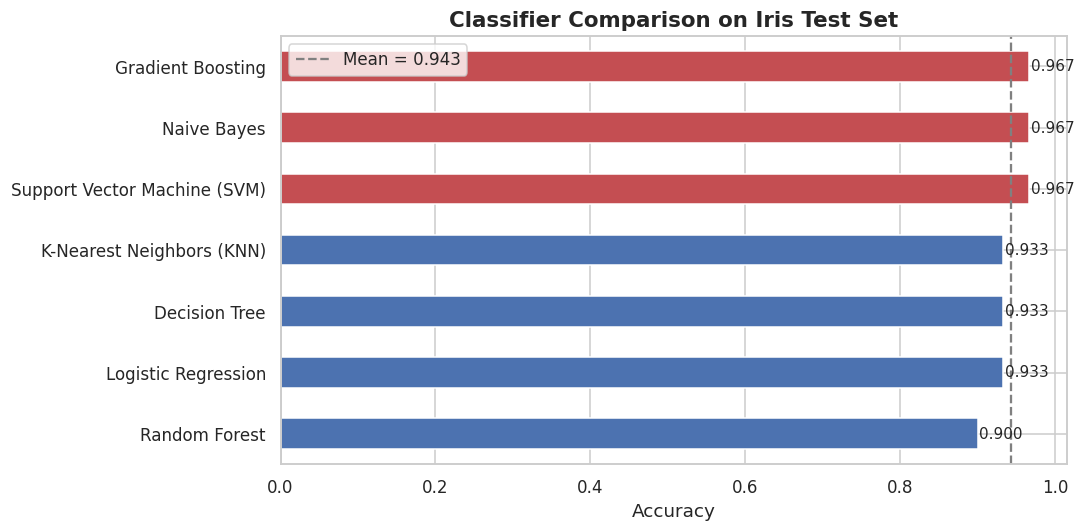

In [23]:
results_series = pd.Series(clf_results).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4C72B0' if v < results_series.max() else '#C44E52' for v in results_series]
results_series.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_xlabel('Accuracy', fontsize=12)
ax.set_title('Classifier Comparison on Iris Test Set', fontsize=14, fontweight='bold')
ax.axvline(results_series.mean(), color='gray', linestyle='--', label=f'Mean = {results_series.mean():.3f}')
ax.legend()
for i, v in enumerate(results_series):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()


---
# 📈 Section 5 / Supervised Learning: Regression

We use the **California Housing** dataset to predict median house values.


In [24]:
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, r2_score

housing = fetch_california_housing(as_frame=True)
df_house = housing.frame
print('Shape:', df_house.shape)
df_house.describe().round(3)


Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000


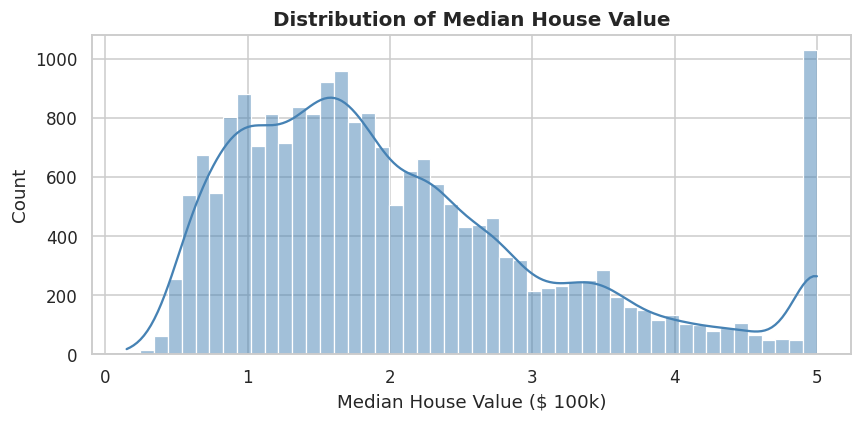

In [25]:
# Target distribution
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df_house['MedHouseVal'], bins=50, kde=True, ax=ax, color='steelblue')
ax.set_title('Distribution of Median House Value', fontsize=13, fontweight='bold')
ax.set_xlabel('Median House Value ($ 100k)')
plt.tight_layout()
plt.show()


In [60]:
# prepare regression data
X_reg = df_house[housing.feature_names].values
y_reg = df_house['MedHouseVal'].values

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_scaler = StandardScaler()
X_reg_train_s = reg_scaler.fit_transform(X_reg_train)
X_reg_test_s  = reg_scaler.transform(X_reg_test)

reg_results = {} 

def eval_regressor(name, model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    mse  = mean_squared_error(yte, pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(yte, pred)
    reg_results[name] = {'MSE': mse, 'RMSE': rmse, 'R2': r2}
    print(f'{name:<30}  MSE={mse:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}')
    return pred




## 5.x Linear Regression

Fits a **straight line** (hyperplane) by minimising the sum of squared residuals (OLS). Fast and interpretable; assumes a linear relationship between features and target.


In [27]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
pred_Linear_Regression = eval_regressor(
    'Linear Regression', model, X_reg_train_s, X_reg_test_s, y_reg_train, y_reg_test
)


Linear Regression               MSE=0.5559  RMSE=0.7456  R²=0.5758


## 5.x Ridge Regression

Linear regression with **L2 regularisation** : penalises large coefficients. Useful when features are correlated (multicollinearity).


In [28]:
from sklearn.linear_model import Ridge
model = Ridge(alpha=1.0)
pred_Ridge_Regression = eval_regressor(
    'Ridge Regression', model, X_reg_train_s, X_reg_test_s, y_reg_train, y_reg_test
)


Ridge Regression                MSE=0.5559  RMSE=0.7456  R²=0.5758


## 5.x Lasso Regression

Linear regression with **L1 regularisation** : can shrink some coefficients to exactly zero, performing automatic feature selection.


In [29]:
from sklearn.linear_model import Lasso
model = Lasso(alpha=0.01, max_iter=5000)
pred_Lasso_Regression = eval_regressor(
    'Lasso Regression', model, X_reg_train_s, X_reg_test_s, y_reg_train, y_reg_test
)


Lasso Regression                MSE=0.5483  RMSE=0.7404  R²=0.5816


## 5.x Decision Tree Regressor

Splits the feature space into rectangular regions and predicts the **mean target value** in each region. Can capture non-linearities but overfits without depth limits.


In [30]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(max_depth=6, random_state=42)
pred_Decision_Tree_Regressor = eval_regressor(
    'Decision Tree Regressor', model, X_reg_train_s, X_reg_test_s, y_reg_train, y_reg_test
)


Decision Tree Regressor         MSE=0.4973  RMSE=0.7052  R²=0.6205


## 5.x Random Forest Regressor

Ensemble of decision trees (bagging) that averages predictions to reduce variance. Typically one of the best out-of-the-box regressors.


In [31]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
pred_Random_Forest_Regressor = eval_regressor(
    'Random Forest Regressor', model, X_reg_train_s, X_reg_test_s, y_reg_train, y_reg_test
)


Random Forest Regressor         MSE=0.2552  RMSE=0.5051  R²=0.8053


## 5.6 Polynomial Regression

Extends linear regression by adding **polynomial feature interactions**, allowing it to fit non-linear data.


In [32]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

poly_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr',   LinearRegression())
])

pred_poly = eval_regressor(
    'Polynomial Regression (deg=2)', poly_pipe,
    X_reg_train_s, X_reg_test_s, y_reg_train, y_reg_test
)


Polynomial Regression (deg=2)   MSE=0.4643  RMSE=0.6814  R²=0.6457


## 5.7 Regression Results Comparison

                                  MSE    RMSE      R2
Random Forest Regressor        0.2552  0.5051  0.8053
Polynomial Regression (deg=2)  0.4643  0.6814  0.6457
Decision Tree Regressor        0.4973  0.7052  0.6205
Lasso Regression               0.5483  0.7404  0.5816
Ridge Regression               0.5559  0.7456  0.5758
Linear Regression              0.5559  0.7456  0.5758


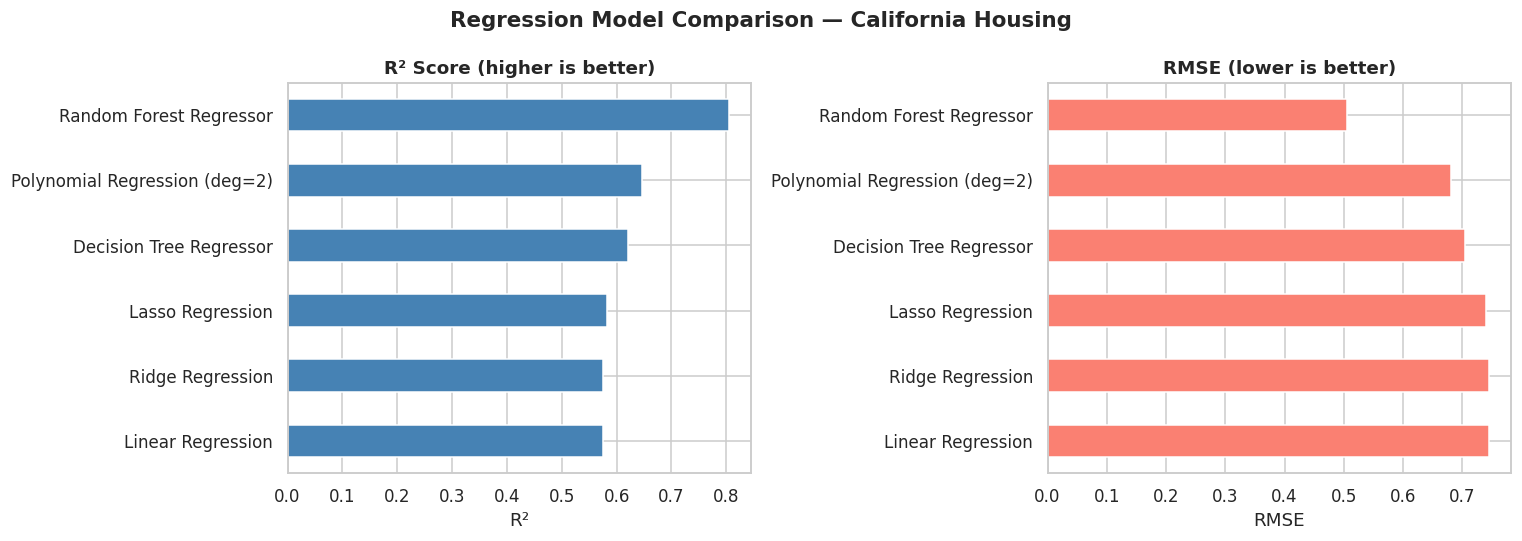

In [33]:
reg_df = pd.DataFrame(reg_results).T.sort_values('R2', ascending=False)
print(reg_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

reg_df['R2'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('R² Score (higher is better)', fontweight='bold')
axes[0].set_xlabel('R²')

reg_df['RMSE'].sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('RMSE (lower is better)', fontweight='bold')
axes[1].set_xlabel('RMSE')

plt.suptitle('Regression Model Comparison — California Housing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


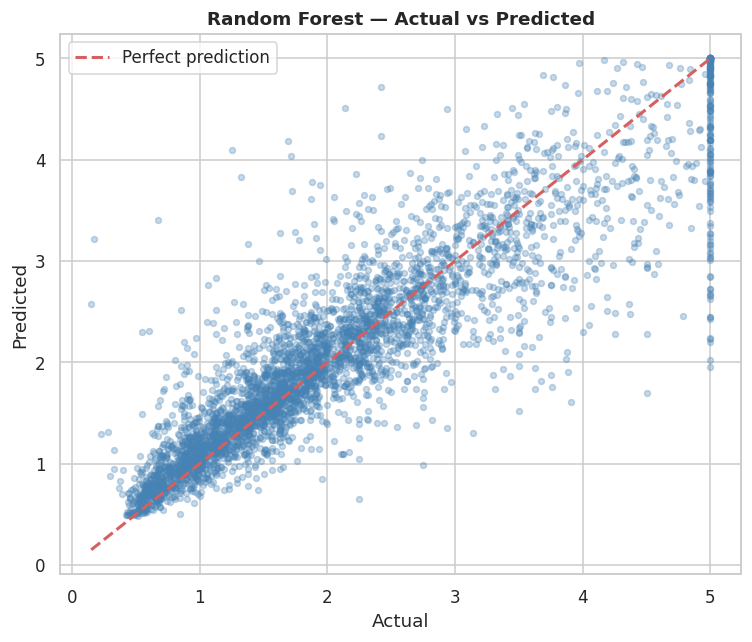

In [34]:
# Actual vs Predicted plot for Random Forest (best model)
from sklearn.ensemble import RandomForestRegressor as RFR
best_rf = RFR(n_estimators=100, random_state=42)
best_rf.fit(X_reg_train_s, y_reg_train)
y_rf_pred = best_rf.predict(X_reg_test_s)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_reg_test, y_rf_pred, alpha=0.3, s=15, color='steelblue')
ax.plot([y_reg_test.min(), y_reg_test.max()],
        [y_reg_test.min(), y_reg_test.max()], 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title('Random Forest — Actual vs Predicted', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


---
# 📐 Section 6 / Model Evaluation

Good evaluation goes beyond raw accuracy. We explore confusion matrices, precision/recall, F1, and ROC-AUC.


## 6.1 Confusion Matrix

A confusion matrix shows counts of **True Positives (TP)**, **True Negatives (TN)**,
**False Positives (FP)**, and **False Negatives (FN)**.

| | Predicted Positive | Predicted Negative |
|--|--|--|
| **Actual Positive** | TP | FN |
| **Actual Negative** | FP | TN |


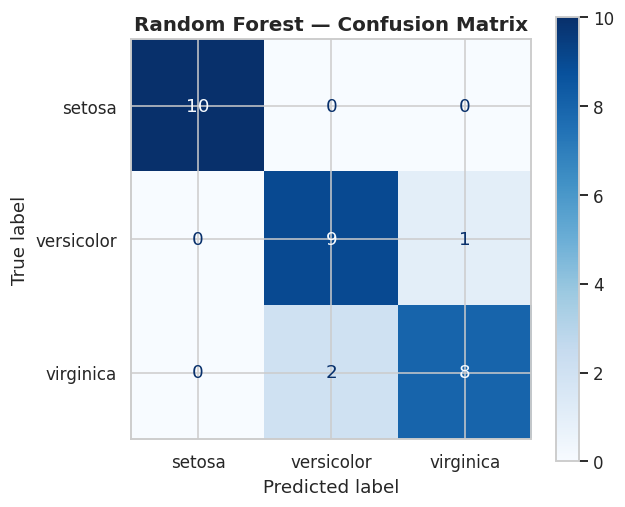

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay

# Use Random Forest predictions (best classifier)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_RandomForestClassifier,
    display_labels=iris.target_names,
    cmap='Blues', ax=ax
)
ax.set_title('Random Forest — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 6.2 Accuracy, Precision, Recall & F1

| Metric | Formula | When to use |
|--------|---------|-------------|
| **Accuracy** | (TP+TN)/(Total) | Balanced classes |
| **Precision** | TP/(TP+FP) | Cost of false positives is high |
| **Recall** | TP/(TP+FN) | Cost of false negatives is high (e.g. disease detection) |
| **F1 Score** | 2·P·R/(P+R) | Balance between precision and recall |


In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred_RandomForestClassifier),
    'Precision': precision_score(y_test, y_pred_RandomForestClassifier, average='macro'),
    'Recall':    recall_score(y_test, y_pred_RandomForestClassifier,    average='macro'),
    'F1 Score':  f1_score(y_test, y_pred_RandomForestClassifier,        average='macro'),
}
for k, v in metrics.items():
    print(f'{k:<12}: {v:.4f}')


Accuracy    : 0.9000
Precision   : 0.9024
Recall      : 0.9000
F1 Score    : 0.8997


## 6.3 ROC Curve & AUC

ROC (Receiver Operating Characteristic) curve plots **TPR vs FPR** at various thresholds.
AUC (Area Under the Curve) summarises performance : 1.0 is perfect, 0.5 is random.


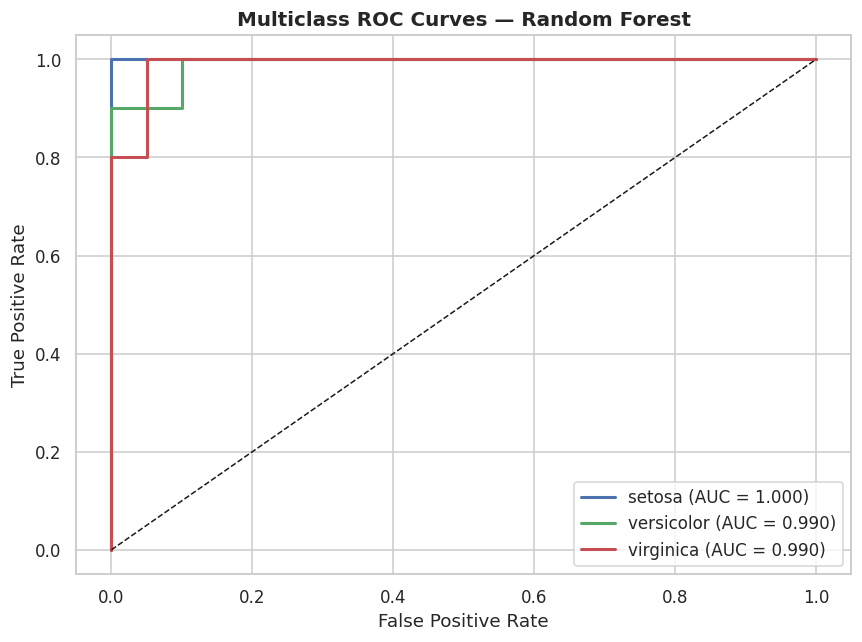

In [37]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Binarize for multiclass ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = model_RandomForestClassifier.predict_proba(X_test_s)

fig, ax = plt.subplots(figsize=(8, 6))
colors = cycle(['#4C72B0', '#55A868', '#C44E52'])
for i, (color, cls) in enumerate(zip(colors, iris.target_names)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Multiclass ROC Curves — Random Forest', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


---
# ⚙️ Section 7 / Feature Engineering

Feature engineering can dramatically improve model performance.


## 7.1 Feature Importance (Tree-Based)

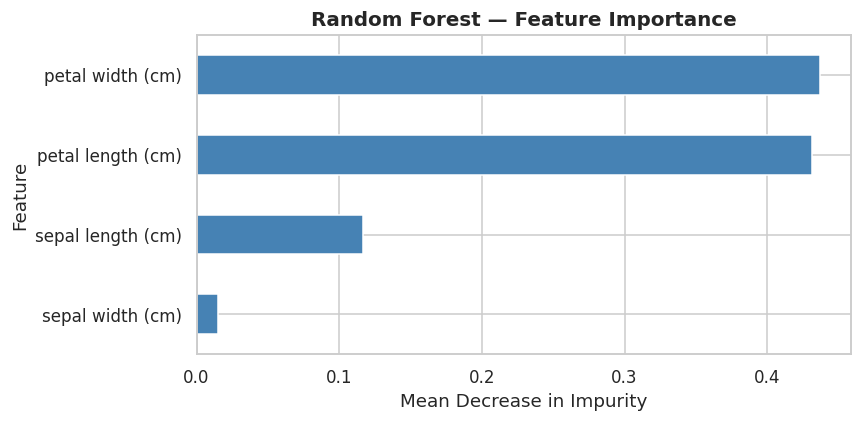

In [38]:
importances = model_RandomForestClassifier.feature_importances_
feat_df = pd.DataFrame({'Feature': iris.feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
feat_df.plot(kind='barh', x='Feature', y='Importance', ax=ax, legend=False, color='steelblue', edgecolor='white')
ax.set_title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()


## 7.2 Principal Component Analysis (PCA)

PCA projects high-dimensional data onto **orthogonal axes** (principal components) that
capture maximum variance. It is used for dimensionality reduction and visualisation.


In [39]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_s)

print(f'Explained variance ratio: {pca.explained_variance_ratio_.round(3)}')
print(f'Total variance explained: {pca.explained_variance_ratio_.sum():.3f}')


Explained variance ratio: [0.727 0.231]
Total variance explained: 0.957


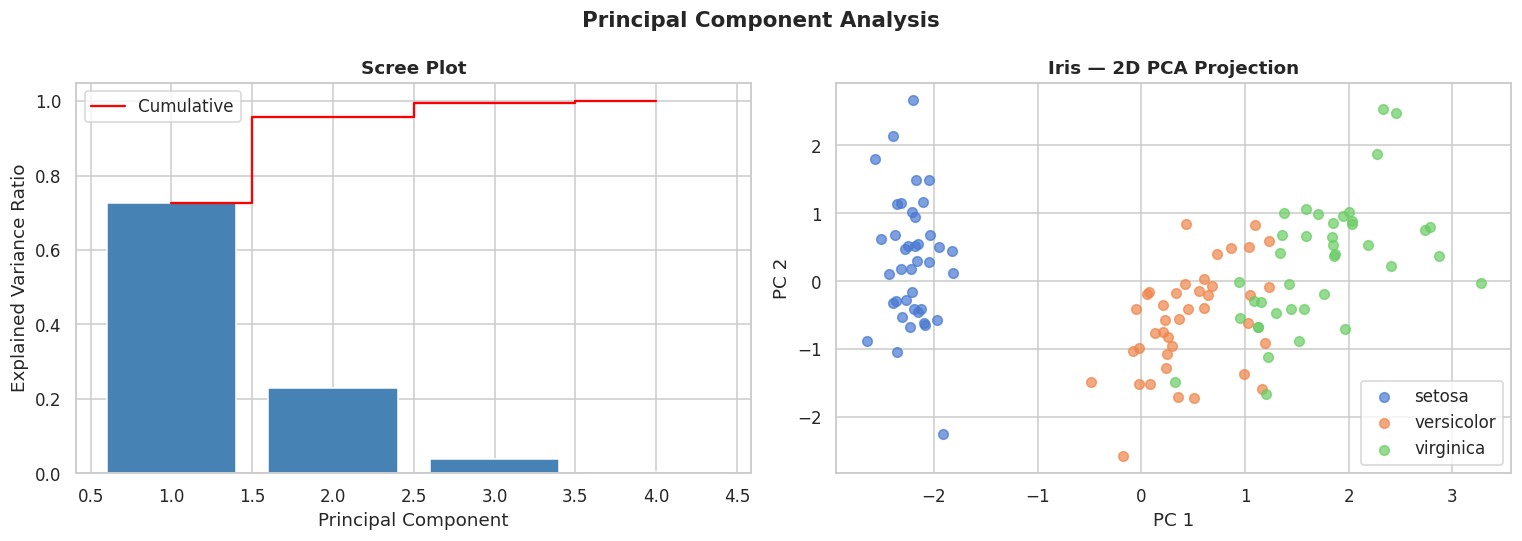

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
pca_full = PCA().fit(X_train_s)
axes[0].bar(range(1, 5), pca_full.explained_variance_ratio_, color='steelblue', edgecolor='white')
axes[0].step(range(1, 5), np.cumsum(pca_full.explained_variance_ratio_), where='mid', color='red', label='Cumulative')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot', fontweight='bold')
axes[0].legend()

# 2D PCA scatter
for label, name in enumerate(iris.target_names):
    mask = y_train == label
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], label=name, alpha=0.7, s=40)
axes[1].set_xlabel('PC 1')
axes[1].set_ylabel('PC 2')
axes[1].set_title('Iris — 2D PCA Projection', fontweight='bold')
axes[1].legend()

plt.suptitle('Principal Component Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
# 🔍 Section 8 / Unsupervised Learning

Unsupervised algorithms discover structure in data without labels.


In [41]:
# use the first 2 PCA components of Iris for 2D clustering visualisation
pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(StandardScaler().fit_transform(df_iris[iris.feature_names]))


## 8.1 K-Means Clustering

K-Means partitions data into **K clusters** by iteratively:
1. Assigning each point to its nearest centroid.
2. Recomputing centroids as the mean of assigned points.

**Elbow method** helps choose the optimal K.


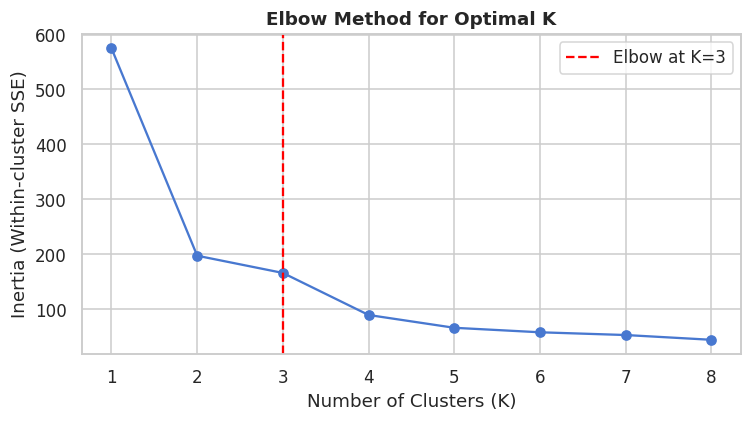

In [42]:
from sklearn.cluster import KMeans

# Elbow method
inertias = []
K_range = range(1, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_2d)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertias, 'bo-')
ax.axvline(3, color='red', linestyle='--', label='Elbow at K=3')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (Within-cluster SSE)')
ax.set_title('Elbow Method for Optimal K', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


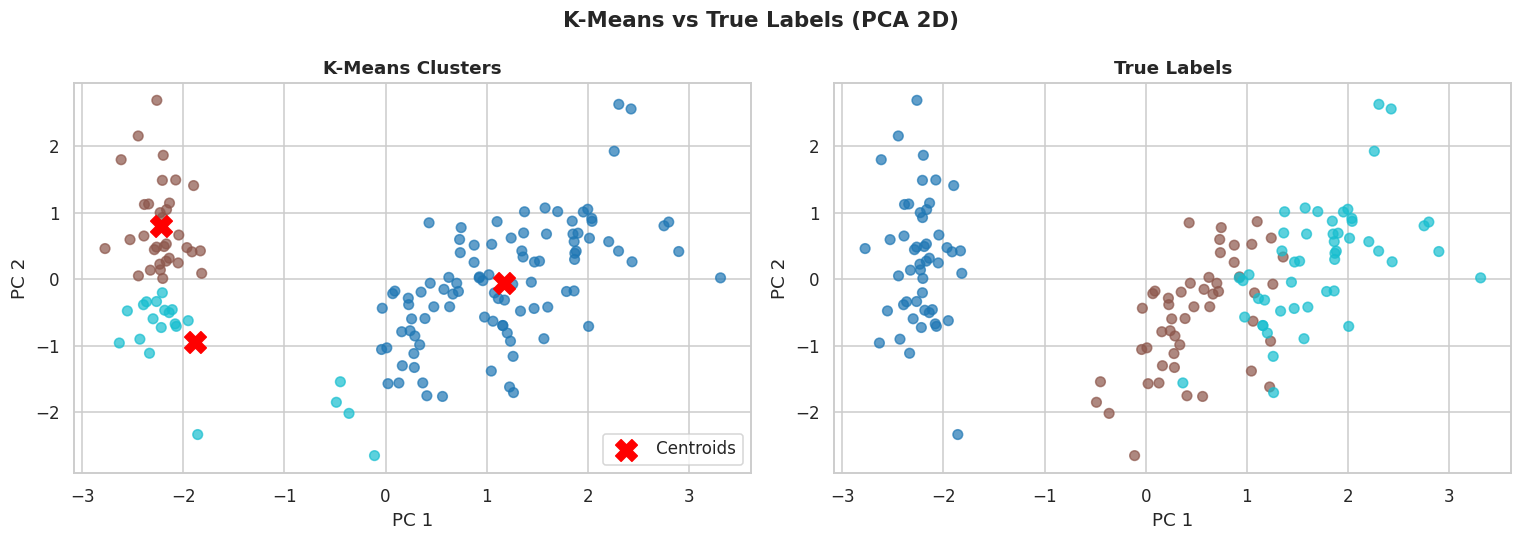

In [43]:
# Fit final K-Means with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
km_labels = kmeans.fit_predict(X_2d)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, labels, title in zip(axes,
                              [km_labels, df_iris['target']],
                              ['K-Means Clusters', 'True Labels']):
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', alpha=0.7, s=40)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')

# Mark centroids
c_2d = pca2.transform(StandardScaler().fit_transform(
    pd.DataFrame(kmeans.cluster_centers_, columns=['x', 'y'])  # dummy workaround
)) if False else axes[0].scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
    c='red', marker='X', s=200, zorder=5, label='Centroids'
)
axes[0].legend()
plt.suptitle('K-Means vs True Labels (PCA 2D)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 8.2 Hierarchical Clustering

Builds a **dendrogram** (tree) by iteratively merging the two closest clusters (*agglomerative*)
or splitting the largest (*divisive*). No need to pre-specify K.


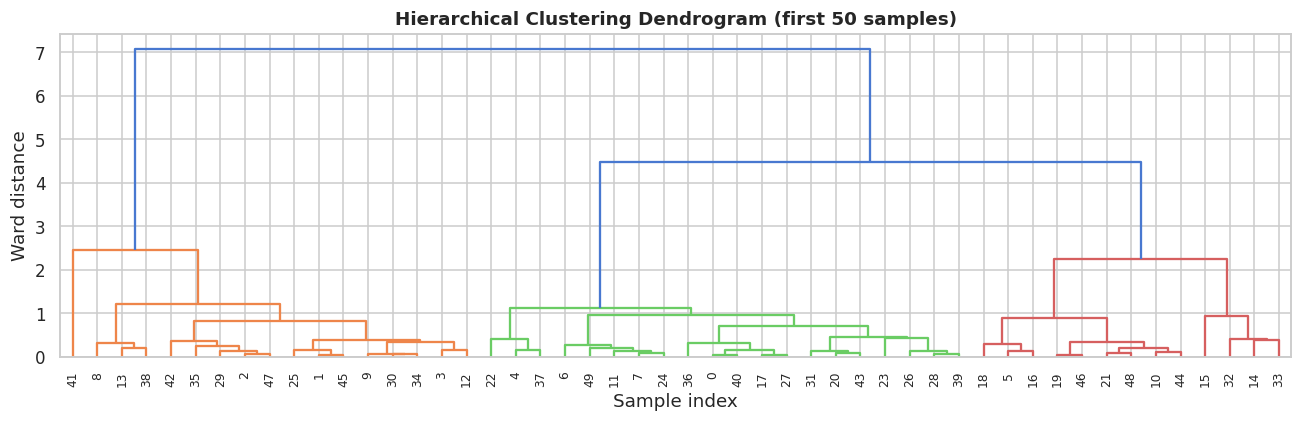

In [44]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Dendrogram on a subset for readability
Z = linkage(X_2d[:50], method='ward')
fig, ax = plt.subplots(figsize=(12, 4))
dendrogram(Z, ax=ax, color_threshold=3)
ax.set_title('Hierarchical Clustering Dendrogram (first 50 samples)', fontweight='bold')
ax.set_xlabel('Sample index')
ax.set_ylabel('Ward distance')
plt.tight_layout()
plt.show()


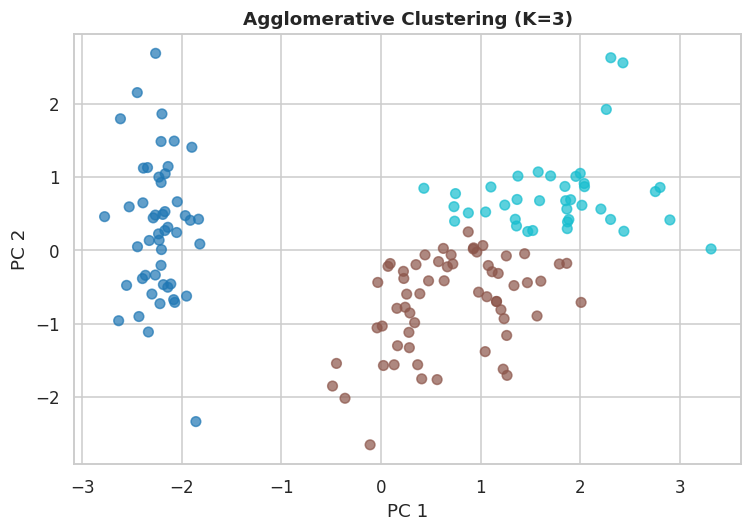

In [45]:
# Agglomerative clustering with 3 clusters
agg = AgglomerativeClustering(n_clusters=3)
agg_labels = agg.fit_predict(X_2d)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=agg_labels, cmap='tab10', alpha=0.7, s=40)
ax.set_title('Agglomerative Clustering (K=3)', fontweight='bold')
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
plt.tight_layout()
plt.show()


## 8.3 DBSCAN

**Density-Based Spatial Clustering** groups closely-packed points and labels sparse outliers as noise.
Unlike K-Means it can find **arbitrarily shaped clusters** and does not require K to be specified.

Key parameters: `eps` (neighbourhood radius), `min_samples` (minimum points to form a core point).


Clusters found: 2  |  Noise points: 12


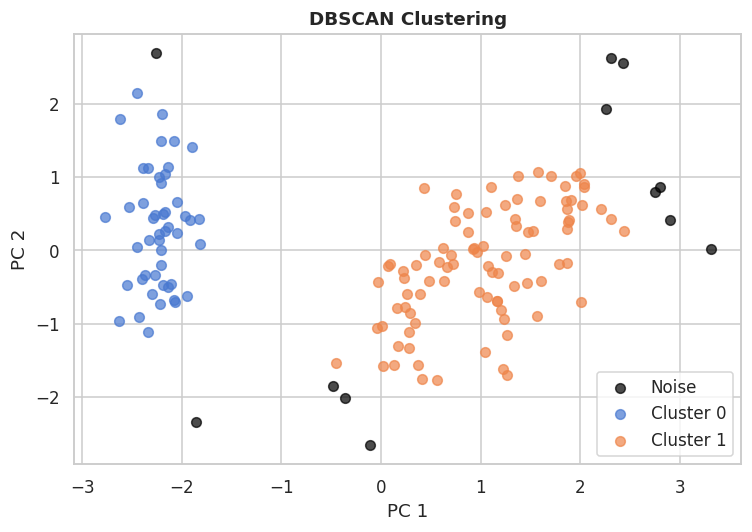

In [46]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_2d)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()
print(f'Clusters found: {n_clusters}  |  Noise points: {n_noise}')

fig, ax = plt.subplots(figsize=(7, 5))
unique = sorted(set(db_labels))
cmap = plt.cm.get_cmap('tab10', len(unique))
for lbl in unique:
    mask = db_labels == lbl
    label_str = f'Cluster {lbl}' if lbl != -1 else 'Noise'
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], label=label_str, alpha=0.7, s=40,
               color='black' if lbl == -1 else None)
ax.set_title('DBSCAN Clustering', fontweight='bold')
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.legend()
plt.tight_layout()
plt.show()


---
# 🔧 Section 9 / Hyperparameter Tuning

Most ML models have **hyperparameters** : settings chosen before training that control model complexity.


## 9.1 GridSearchCV

Exhaustively searches a defined grid of hyperparameter values using **cross-validation**.
Computationally expensive but guaranteed to find the best combination in the grid.


In [47]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C':      [0.1, 1, 10, 100],
    'gamma':  ['scale', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}

grid_search = GridSearchCV(
    SVC(random_state=42), param_grid,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
grid_search.fit(X_train_s, y_train)

print('Best parameters:', grid_search.best_params_)
print(f'Best CV accuracy: {grid_search.best_score_:.4f}')
print(f'Test accuracy:    {grid_search.score(X_test_s, y_test):.4f}')


Best parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV accuracy: 0.9833
Test accuracy:    0.9667


## 9.2 RandomizedSearchCV

Samples a **fixed number of parameter settings** from specified distributions.
Much faster than GridSearchCV for large search spaces, often finds equally good results.


In [48]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth':    [None, 3, 5, 10, 20],
    'min_samples_split': randint(2, 10),
    'max_features': ['sqrt', 'log2']
}

rand_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42), param_dist,
    n_iter=30, cv=5, scoring='accuracy', random_state=42, n_jobs=-1
)
rand_search.fit(X_train_s, y_train)

print('Best parameters:', rand_search.best_params_)
print(f'Best CV accuracy: {rand_search.best_score_:.4f}')
print(f'Test accuracy:    {rand_search.score(X_test_s, y_test):.4f}')


Best parameters: {'max_depth': 3, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 139}
Best CV accuracy: 0.9583
Test accuracy:    0.9667


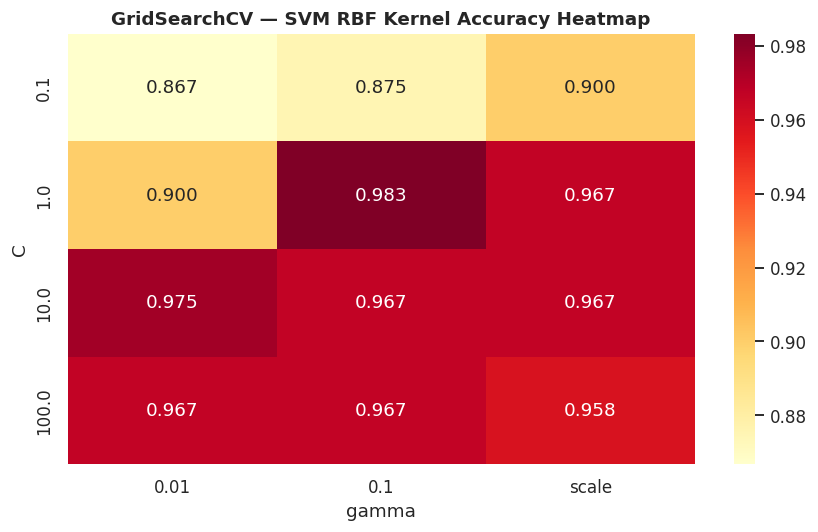

In [49]:
# Visualise GridSearch results for SVM
results_df = pd.DataFrame(grid_search.cv_results_)
pivot = results_df[results_df['param_kernel'] == 'rbf'].pivot_table(
    values='mean_test_score',
    index='param_C',
    columns='param_gamma'
)
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax)
ax.set_title('GridSearchCV — SVM RBF Kernel Accuracy Heatmap', fontweight='bold')
ax.set_xlabel('gamma')
ax.set_ylabel('C')
plt.tight_layout()
plt.show()


---
# 🔩 Section 10 / Machine Learning Pipeline

A `Pipeline` chains preprocessing and modelling steps into a single object.
Benefits:
- Prevents **data leakage** (preprocessing fitted only on training data)
- Simplifies cross-validation and deployment
- Clean, reproducible code


In [50]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

# Build pipeline: scale → PCA (optional dim reduction) → Gradient Boosting
full_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=3)),
    ('clf',    GradientBoostingClassifier(n_estimators=100, random_state=42))
])

# 5-fold cross-validation on raw (unscaled) data — pipeline handles scaling internally
cv_scores = cross_val_score(full_pipeline, X_clf, y_clf, cv=5, scoring='accuracy')

print(f'CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Individual folds: {cv_scores.round(4)}')


CV Accuracy: 0.9600 ± 0.0327
Individual folds: [0.9667 0.9667 0.9    0.9667 1.    ]


Pipeline test accuracy: 0.9333


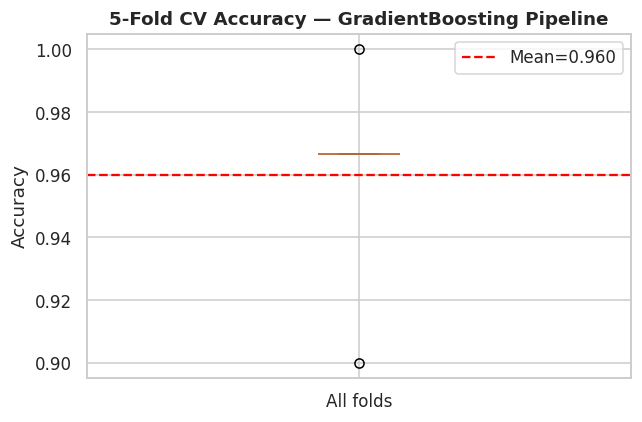

In [51]:
# Fit the pipeline and evaluate on held-out test set
full_pipeline.fit(X_train, y_train)   # pass raw (unscaled) training data
pipe_acc = full_pipeline.score(X_test, y_test)
print(f'Pipeline test accuracy: {pipe_acc:.4f}')

# Cross-validation box plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(cv_scores, vert=True, patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue'))
ax.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean={cv_scores.mean():.3f}')
ax.set_title('5-Fold CV Accuracy — GradientBoosting Pipeline', fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_xticklabels(['All folds'])
ax.legend()
plt.tight_layout()
plt.show()


---
# 🚀 Section 11 : Mini Project: Breast Cancer Diagnosis

**Goal:** Build an end-to-end binary classification system to diagnose breast cancer
(Malignant vs Benign) using the Wisconsin Breast Cancer dataset.

**Dataset:** 569 samples · 30 numeric features · 2 classes (Malignant=0, Benign=1)


### Step 1 : Data Loading & Exploration

In [52]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True)
df_bc = cancer.frame
df_bc['target_name'] = df_bc['target'].map({0: 'Malignant', 1: 'Benign'})

print('Shape:', df_bc.shape)
print('Class distribution:')
print(df_bc['target_name'].value_counts())
df_bc.head(3)


Shape: (569, 32)
Class distribution:
target_name
Benign       357
Malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant


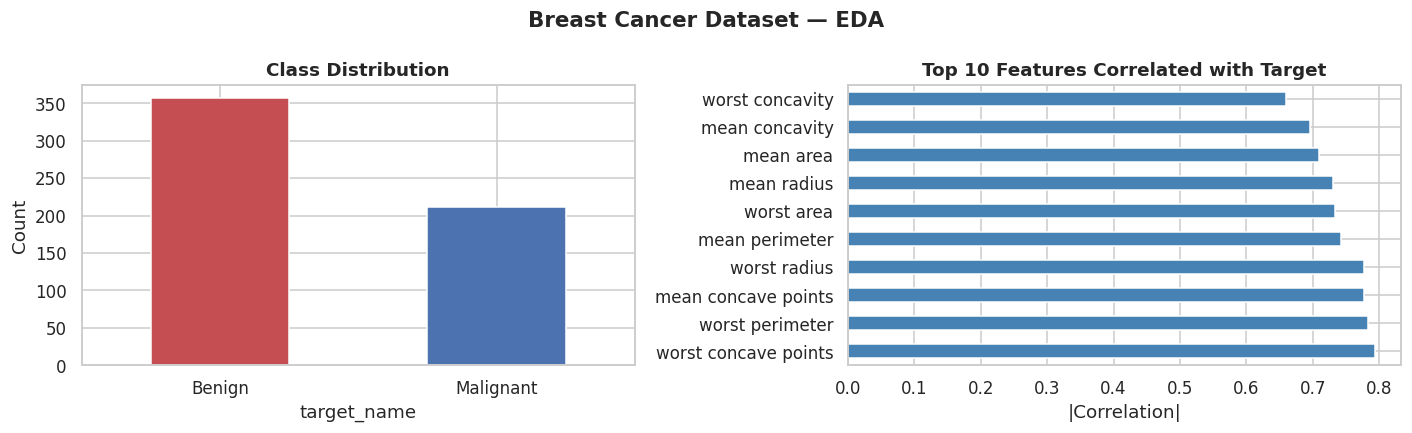

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))


df_bc['target_name'].value_counts().plot(kind='bar', ax=axes[0], color=['#C44E52','#4C72B0'], edgecolor='white', rot=0)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')


top_feats = df_bc.drop(columns=['target', 'target_name']).corrwith(df_bc['target']).abs().sort_values(ascending=False).head(10)
top_feats.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Top 10 Features Correlated with Target', fontweight='bold')
axes[1].set_xlabel('|Correlation|')

plt.suptitle('Breast Cancer Dataset — EDA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Step 2 / Preprocessing

In [54]:
X_bc = df_bc[cancer.feature_names].values
y_bc = df_bc['target'].values

X_bc_tr, X_bc_te, y_bc_tr, y_bc_te = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)

bc_scaler = StandardScaler()
X_bc_tr_s = bc_scaler.fit_transform(X_bc_tr)
X_bc_te_s = bc_scaler.transform(X_bc_te)

print(f'Train: {X_bc_tr.shape}  |  Test: {X_bc_te.shape}')


Train: (455, 30)  |  Test: (114, 30)


### Step 3 / Model Training & Comparison

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

bc_models = {
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':         RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)':             SVC(probability=True, random_state=42),
}

bc_results = []
print(f'{"Model":<25}  {"Accuracy":>10}  {"F1":>8}  {"AUC":>8}')
print('-' * 58)
for name, clf in bc_models.items():
    clf.fit(X_bc_tr_s, y_bc_tr)
    pred = clf.predict(X_bc_te_s)
    prob = clf.predict_proba(X_bc_te_s)[:, 1]
    acc  = accuracy_score(y_bc_te, pred)
    f1   = f1_score(y_bc_te, pred)
    auc  = roc_auc_score(y_bc_te, prob)
    bc_results.append({'Model': name, 'Accuracy': acc, 'F1': f1, 'AUC': auc})
    print(f'{name:<25}  {acc:>10.4f}  {f1:>8.4f}  {auc:>8.4f}')


Model                        Accuracy        F1       AUC
----------------------------------------------------------
Logistic Regression            0.9825    0.9861    0.9954
Random Forest                  0.9561    0.9655    0.9939
Gradient Boosting              0.9561    0.9660    0.9907
SVM (RBF)                      0.9825    0.9861    0.9950


### Step 4 / Evaluation & Visualisation

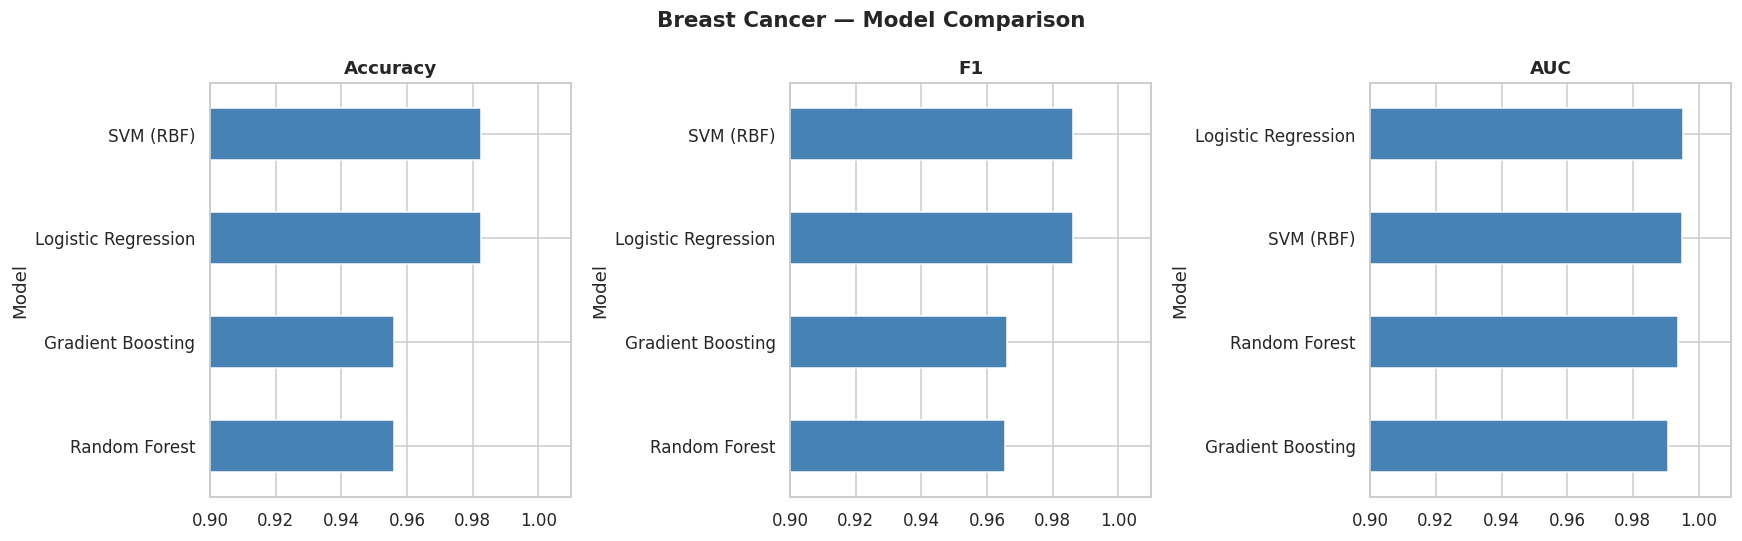

In [56]:
bc_df = pd.DataFrame(bc_results).set_index('Model')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ['Accuracy', 'F1', 'AUC']):
    bc_df[metric].sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_xlim(0.9, 1.01)
plt.suptitle('Breast Cancer — Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


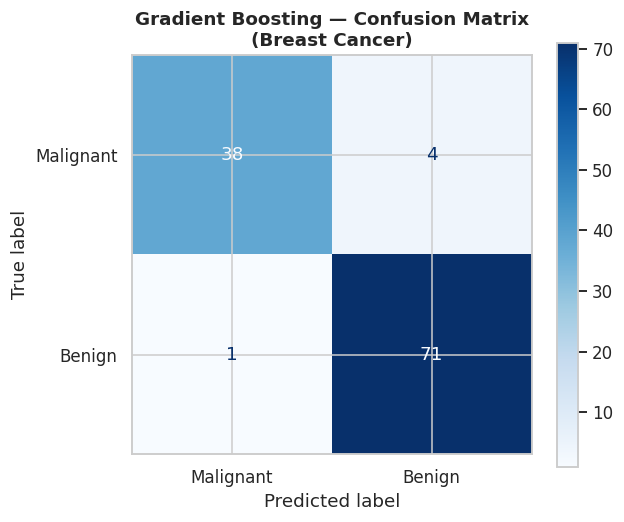

In [57]:

best_bc_model = bc_models['Gradient Boosting']
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    best_bc_model, X_bc_te_s, y_bc_te,
    display_labels=['Malignant', 'Benign'],
    cmap='Blues', ax=ax
)
ax.set_title('Gradient Boosting — Confusion Matrix\n(Breast Cancer)', fontweight='bold')
plt.tight_layout()
plt.show()


### Step 5 / Final Prediction on New Patient Data

In [58]:
new_patient = X_bc_te[:3]   # take 3 real test samples as 'new' patients
new_patient_s = X_bc_te_s[:3]

predictions = best_bc_model.predict(new_patient_s)
probabilities = best_bc_model.predict_proba(new_patient_s)

label_map = {0: 'Malignant ⚠️', 1: 'Benign ✅'}
for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    print(f'Patient {i+1}: {label_map[pred]}  '
          f'(P(Malignant)={prob[0]:.3f}, P(Benign)={prob[1]:.3f})')
    print(f'  True label: {label_map[y_bc_te[i]]}')
    print()


Patient 1: Malignant ⚠️  (P(Malignant)=1.000, P(Benign)=0.000)
  True label: Malignant ⚠️

Patient 2: Benign ✅  (P(Malignant)=0.000, P(Benign)=1.000)
  True label: Benign ✅

Patient 3: Malignant ⚠️  (P(Malignant)=0.997, P(Benign)=0.003)
  True label: Malignant ⚠️



---
# 🎓 Summary & Next Steps

Congratulations on completing the **Machine Learning Practical Handbook**! 🎉

### What you learned
| Section | Topic |
|---------|-------|
| 1 | ML definitions, types, and workflow |
| 2 | EDA, pairplots, correlation heatmaps |
| 3 | Imputation, encoding, scaling, train/test split |
| 4 | 7 classification algorithms with evaluation |
| 5 | 6 regression algorithms: MSE, RMSE, R² |
| 6 | Confusion matrix, precision, recall, F1, ROC-AUC |
| 7 | Feature importance, PCA |
| 8 | K-Means, Hierarchical, DBSCAN |
| 9 | GridSearchCV, RandomizedSearchCV |
| 10 | End-to-end Pipeline |
| 11 | Mini Project — Breast Cancer Diagnosis |

### Recommended next steps
- **XGBoost / LightGBM / CatBoost** — gradient boosting libraries that dominate Kaggle
- **Neural Networks** — start with `scikit-learn`'s `MLPClassifier`, then move to PyTorch / TensorFlow
- **Time Series** — `statsmodels`, `prophet`, `sktime`
- **MLOps** — model versioning with MLflow, deployment with FastAPI / Docker
- **Kaggle competitions** — apply these skills on real-world datasets!

---

